In [1]:
import pandas as pd
import numpy as np
from pathlib import Path 

np.random.seed(42)
frequency = 64
path = Path(f"data/raw/dreamt/data_{frequency}Hz")

COLS_TO_DROP = [
    "TIMESTAMP",
    "IBI",
    "Obstructive_Apnea",
    "Central_Apnea",
    "Hypopnea",
    "Multiple_Events",
]
nb_patients = 100
X_all_patients = []
y_all_patients = []
patient_file_list = [f for f in path.iterdir() if f.is_file()]
for patient_id in range(nb_patients):
    patient_file = patient_file_list.pop() 
    df = pd.read_csv(patient_file)
    df = df.drop(
                columns=COLS_TO_DROP
            )
    df = df[~df["Sleep_Stage"].isin(["Missing","P"])]
    y_all_patients.append(df.Sleep_Stage.to_numpy())
    X_all_patients.append(df.drop(columns=["Sleep_Stage"]).to_numpy())



In [2]:
WINDOWS_SEC = 30
FS = 64

window_samples = FS * WINDOWS_SEC

X_bvp_patients = []
X_acc_patients = []
X_eda_temp_patients = []
X_hr_patients = []
y_patients = []

for patient in range(len(X_all_patients)):
    X_bvp = []
    X_acc = []
    X_eda_temp = []
    X_hr = []
    y = []
    data = X_all_patients[patient]
    T = data.shape[0]
    n_windows = T // window_samples
    for i in range(n_windows):
        start = i * window_samples
        end = start + window_samples
        # 1920, 
        X_bvp.append(data[start:end,0])
        # 960
        X_acc.append(data[start:end:2, 1:4])
        # 120
        X_eda_temp.append(data[start:end:16, 4:6])
        # 30
        X_hr.append(data[start:end:64, 6])
        #1
        y.append(y_all_patients[patient][start])
    
    X_bvp_patients.append(np.stack(X_bvp))
    X_acc_patients.append(np.stack(X_acc))
    X_hr_patients.append(np.stack(X_hr))
    X_eda_temp_patients.append(np.stack(X_eda_temp))
    y_patients.append(np.array(y))
        


In [3]:
X_bvp_train = []
X_bvp_test = []

X_acc_train = []
X_acc_test = []

X_eda_temp_train = []
X_eda_temp_test = []

X_hr_train = []
X_hr_test = []

y_train = []
y_test = []

test_size = 0.2

test_patients = np.random.choice(nb_patients, size= int(test_size * nb_patients))

for patient in range(nb_patients):
    if patient not in test_patients:
        X_bvp_train.append(X_bvp_patients[patient])
        X_acc_train.append(X_acc_patients[patient])
        X_eda_temp_train.append(X_eda_temp_patients[patient])
        X_hr_train.append(X_hr_patients[patient])
        y_train.append(y_patients[patient])

    else:
        X_bvp_test.append(X_bvp_patients[patient])
        X_acc_test.append(X_acc_patients[patient])
        X_eda_temp_test.append(X_eda_temp_patients[patient])
        X_hr_test.append(X_hr_patients[patient])
        y_test.append(y_patients[patient])



X_bvp_train =np.concatenate(X_bvp_train)
X_bvp_test =np.concatenate(X_bvp_test)

X_acc_train =np.concatenate(X_acc_train)
X_acc_test =np.concatenate(X_acc_test)

X_eda_temp_train =np.concatenate(X_eda_temp_train)
X_eda_temp_test =np.concatenate(X_eda_temp_test)

X_hr_train =np.concatenate(X_hr_train)
X_hr_test =np.concatenate(X_hr_test)

y_train = np.concatenate(y_train)
y_test = np.concatenate(y_test)

In [4]:
X_bvp_train = np.expand_dims(X_bvp_train, axis=1)
X_eda_temp_train = np.permute_dims(X_eda_temp_train, axes=[0,2,1])
X_acc_train = np.permute_dims(X_acc_train, axes=[0,2,1])

X_bvp_test      = np.expand_dims(X_bvp_test, axis=1)
X_eda_temp_test = np.permute_dims(X_eda_temp_test, axes=[0,2,1])
X_acc_test      = np.permute_dims(X_acc_test, axes=[0,2,1])

In [5]:
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()
y_train_encoded = lb.fit_transform(y_train)
y_test_encoded = lb.transform(y_test)

y_train_encoded

array([4, 4, 4, ..., 4, 4, 4], shape=(65681,))

In [6]:
import torch 
import torch.nn as nn 

class ResBlock1d(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size= kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size = kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))

class ResBlock2d(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        #32, 33,29 => 32, 33, 29
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size= (1, kernel_size), padding=(0, kernel_size//2)),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size = (1, kernel_size), padding=(0, kernel_size//2)),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))


class MultiScaleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # input (B, 1, 1920)
        self.bvp_path = nn.Sequential(
            nn.BatchNorm1d(1),
            nn.Conv1d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),                                        # →480
            ResBlock1d(32),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),                                        # →120
            ResBlock1d(64),
            nn.Conv1d(64, 128, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),                                        # →30
            ResBlock1d(128),
        )  # (B, 128, 30)

        # input (B, 3, 17, 59)
        self.acc_path = nn.Sequential(
            nn.BatchNorm2d(3),
            nn.Conv2d(3, 32, kernel_size=(1 , 3), padding=(0,1)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2)),                                        
            ResBlock2d(32),
            # nn.Conv2d(32, 64, kernel_size=(1, 3), stride=(1,2), padding=(0,2)),
            # nn.BatchNorm2d(64),
            # nn.ReLU(),
            # ResBlock2d(64),
        )  # (B, 64, 17, 16)

        # input (B, 2, 120)
        self.eda_temp_path = nn.Sequential(
            nn.BatchNorm1d(2),
            nn.Conv1d(2, 16, kernel_size=3, stride=2, padding=1),  # →60
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),                                        # →30
        )  # (B, 16, 30) — too shallow for residuals

        self.fc = nn.Sequential(
            nn.Linear(128*30 + 32*17*29 + 16*30 + 30, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 5), 
        )

        self.hr_bn = nn.BatchNorm1d(1)
        self.init_weights()

    def init_weights(self):
        for layer in self.modules():
            if isinstance(layer, (nn.Conv1d, nn.Conv2d, nn.Linear)):
                if not isinstance(layer, nn.modules.lazy.LazyModuleMixin):
                    nn.init.kaiming_normal_(layer.weight)
                    nn.init.zeros_(layer.bias)
            elif isinstance(layer, (nn.BatchNorm1d, nn.BatchNorm2d)):
                nn.init.ones_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x_bvp, x_acc, x_eda_temp, x_hr):
        x_hr = self.hr_bn(x_hr.unsqueeze(1)).squeeze(1)
        out_bvp      = self.bvp_path(x_bvp).flatten(1)
        out_acc      = self.acc_path(x_acc).flatten(1)
        out_eda_temp = self.eda_temp_path(x_eda_temp).flatten(1)
        merged = torch.cat([out_bvp, out_acc, out_eda_temp, x_hr.flatten(1)], dim=1)
        return self.fc(merged)

In [7]:
def mask_spectrogram(X, P_T = 0.2, P_F = 0.1, W_T = 5, W_F = 2):
    n_channels, n_freq, n_frames = X.shape
    T_num = int(P_T * n_frames) // W_T
    F_num = int(P_F * n_freq) // W_F
    if torch.rand(1).item() > 0.8:
            return X
    
    M = torch.zeros((n_channels, n_freq, n_frames))
    T_indices = np.random.choice(n_frames - W_T, size=T_num, replace=False)
    F_indices = np.random.choice(n_freq - W_F, size=F_num, replace=False)
    for T in T_indices:
                M[:,:, T:T+W_T] = 1
    for F in F_indices:
                M[:,F:F+W_F,:] = 1

    return X * (1 - M)

In [8]:
from torch.utils.data import Dataset, DataLoader
class DreamtDataset(Dataset):
    def __init__(self, X_bvp, X_acc, X_eda_temp, X_hr, y, n_fft):
        super().__init__()
        self.X_bvp      = X_bvp
        self.X_acc      = X_acc
        self.X_eda_temp = X_eda_temp
        self.X_hr       = X_hr
        self.y          = y
        self.n_fft = n_fft
        self.window_hann = torch.hann_window(n_fft)

    def __getitem__(self, index):
        acc_stft = torch.stft(
            self.X_acc[index],
            n_fft=self.n_fft,
            hop_length=self.n_fft // 2,
            window=self.window_hann,
            onesided=True,
            center= False,
            normalized=True,
            return_complex=True
        ).abs() ** 2  # (3, n_freqs, n_frames) (,59)
        acc_stft = 10 * torch.log10(acc_stft + 1e-8)
        return (
            self.X_bvp[index],
            acc_stft,
            self.X_eda_temp[index],
            self.X_hr[index],
            self.y[index],
        )

    def __len__(self):
        return len(self.X_bvp)


n_fft_acc = 32 

X_bvp_train      = torch.FloatTensor(X_bvp_train)
X_acc_train      = torch.FloatTensor(X_acc_train)
X_eda_temp_train = torch.FloatTensor(X_eda_temp_train)
X_hr_train       = torch.FloatTensor(X_hr_train)
y_train_encoded  = torch.LongTensor(y_train_encoded)  

train_ds = DreamtDataset(X_bvp_train, X_acc_train, X_eda_temp_train, X_hr_train, y_train_encoded, n_fft_acc)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)



In [9]:
from sklearn.utils.class_weight import compute_class_weight

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = np.unique(y_train_encoded.numpy())
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_encoded.numpy())
weights = torch.FloatTensor(weights).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights, reduction="sum")

In [10]:
from tqdm import tqdm



X_bvp_test       = torch.FloatTensor(X_bvp_test)
X_acc_test       = torch.FloatTensor(X_acc_test)
X_eda_temp_test  = torch.FloatTensor(X_eda_temp_test)
X_hr_test        = torch.FloatTensor(X_hr_test)
y_test_encoded   = torch.LongTensor(y_test_encoded)

test_ds = DreamtDataset(X_bvp_test, X_acc_test, X_eda_temp_test, X_hr_test, y_test_encoded, n_fft_acc)
test_dl = DataLoader(test_ds, batch_size=1024)


def train_model(model, train_dl, epochs, weights= None, lr=0.001, device=torch.device("cpu")):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    if weights is None:
        criterion = nn.CrossEntropyLoss(reduction="sum")
    else: 
        criterion = nn.CrossEntropyLoss(weight=weights, reduction="sum")
    for epoch in tqdm(range(epochs)):
        model.train()
        empirical_risk = 0.0
        for x_bvp, x_acc, x_eda_temp, x_hr, y in train_dl:
            x_bvp = x_bvp.to(device)
            x_acc = x_acc.to(device)
            x_eda_temp = x_eda_temp.to(device)
            x_hr = x_hr.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            pred = model(x_bvp, x_acc, x_eda_temp, x_hr)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            empirical_risk += loss.item()

        empirical_risk /= len(train_dl.dataset)
        print("Train loss: %.3f" % (empirical_risk))

def test_model(model, test_dl, device=torch.device("cpu")):
    criterion = nn.CrossEntropyLoss(reduction="sum")
    model.eval()
    generalization_error = 0.0
    correct = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_bvp, x_acc, x_eda_temp, x_hr, y in test_dl:
            x_bvp = x_bvp.to(device)
            x_acc = x_acc.to(device)
            x_eda_temp = x_eda_temp.to(device)
            x_hr = x_hr.to(device)
            y = y.to(device)
            logits = model(x_bvp, x_acc, x_eda_temp, x_hr)
            loss = criterion(logits, y)
            pred = torch.argmax(logits, dim=1)
            correct += (pred == y).sum().item()
            generalization_error += loss.item()
            all_preds.append(pred.cpu())
            all_targets.append(y.cpu())

        y_pred = torch.cat(all_preds).numpy()
        y_true = torch.cat(all_targets).numpy()
        generalization_error /= len(test_dl.dataset)
        accuracy = correct / len(test_dl.dataset)
        print(
            "Generalization Error: %.3f, Accuracy %.3f"
            % (generalization_error, accuracy)
        )

    return y_true, y_pred


model = MultiScaleCNN()
model.to(DEVICE)

train_model(model, train_dl, weights=weights, epochs=50, device = DEVICE)


  2%|▏         | 1/50 [01:50<1:30:02, 110.27s/it]

Train loss: 1.995


  4%|▍         | 2/50 [03:40<1:28:03, 110.07s/it]

Train loss: 1.591


  6%|▌         | 3/50 [05:27<1:25:22, 108.99s/it]

...

Train loss: 0.494


 98%|█████████▊| 49/50 [1:28:16<01:46, 106.67s/it]

Train loss: 0.480


100%|██████████| 50/50 [1:30:02<00:00, 108.06s/it]

Train loss: 0.468


In [12]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

nrem_classes = [0,1,2]
merge_fn = np.vectorize(lambda x: 0 if x in nrem_classes else x) 

y_true, y_pred = test_model(model, test_dl, DEVICE)

y_true_merged = merge_fn(y_true)
y_pred_merged = merge_fn(y_pred)


print(classification_report(y_true_merged, y_pred_merged, target_names=["N","R","W"]))

Generalization Error: 1.774, Accuracy 0.459
              precision    recall  f1-score   support

           N       0.69      0.75      0.72      9040
           R       0.11      0.10      0.11      1269
           W       0.56      0.47      0.51      4200

    accuracy                           0.61     14509
   macro avg       0.45      0.44      0.45     14509
weighted avg       0.60      0.61      0.60     14509



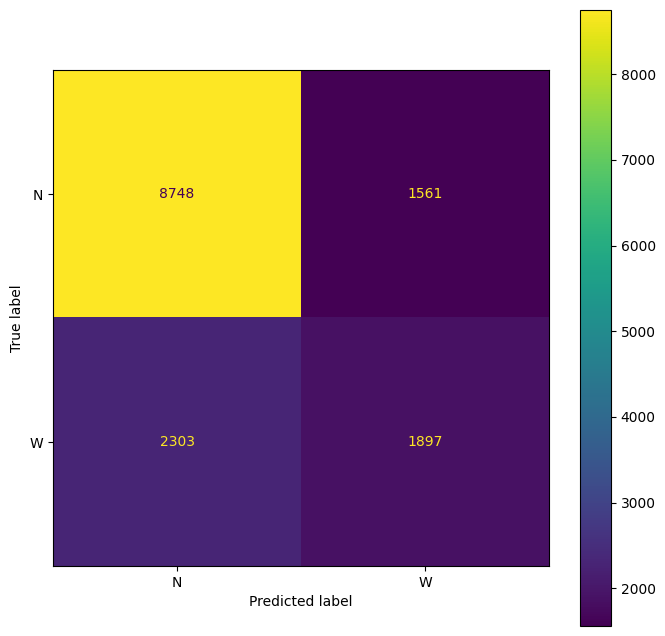

In [ ]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix(y_true_merged, y_pred_merged), display_labels=["N","W"]).plot(ax=ax)
fig.savefig(f"reports/figures/confusion_matrix_U=25_C=2_M=MultiCCN.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [14]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true, y_pred = test_model(model, test_dl, DEVICE)


print(classification_report(y_true, y_pred, target_names=lb.classes_))

Generalization Error: 2.309, Accuracy 0.410
              precision    recall  f1-score   support

          N1       0.09      0.22      0.13       293
          N2       0.56      0.50      0.53      2031
          N3       0.26      0.32      0.29       241
           R       0.17      0.15      0.16       552
           W       0.54      0.44      0.48      1156

    accuracy                           0.41      4273
   macro avg       0.32      0.33      0.32      4273
weighted avg       0.45      0.41      0.43      4273



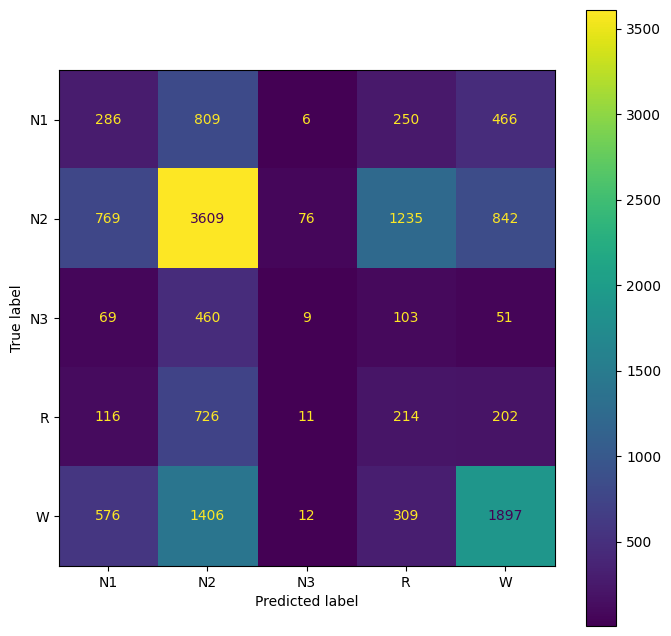

In [ ]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=lb.classes_).plot(ax=ax)
fig.savefig(f"reports/figures/confusion_matrix_U=25_C=5_M=MultiCCN.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)